In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [17]:
df = pd.read_csv("Transactions Data.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [19]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [20]:
df['type'].value_counts()


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [21]:
df['isFraud'].value_counts()
# df['isFraud'].value_counts(normalize=True)

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [22]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

feature engineering


In [23]:
df_model = df.drop(columns=['nameOrig','nameDest','isFlaggedFraud'])
# nameorig and namedest have unique number so model cant train anything from them. isflaggedfraud is the o/p of existing system not predictive.

In [24]:
df_model['errorBalanceOrig']= df_model['newbalanceOrig']+df_model['amount']-df_model['oldbalanceOrg']
df_model['errorBalanceDest']= df_model['oldbalanceDest']+df_model['amount']-df_model['newbalanceDest']
#new balance = old balance - amount (for the sender)
#new balance = old balance + amount (for the receiver)

In [25]:
print("Before:", df_model.shape)
df_model = df_model.dropna()
print("After:", df_model.shape)

# Confirm no nulls remain
df_model.isnull().sum()

Before: (6362620, 10)
After: (6362620, 10)


step                0
type                0
amount              0
oldbalanceOrg       0
newbalanceOrig      0
oldbalanceDest      0
newbalanceDest      0
isFraud             0
errorBalanceOrig    0
errorBalanceDest    0
dtype: int64

In [26]:
X=df_model.drop(columns=['isFraud'])
y=df_model['isFraud']

In [27]:
categorical_cols = ['type']
numeric_cols = [c for c in X.columns if c not in categorical_cols]
#seperate column names by type so the columntransformer later knows which preprocessing to apply where.

In [28]:
print(X.shape, y.value_counts(normalize=True))

(6362620, 9) isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [29]:
# Find rows with any null value
null_rows = df_model[df_model.isnull().any(axis=1)]
print(null_rows.shape)
null_rows

(0, 10)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'),
     categorical_cols)
])
# Make number columns comparable, turn category text into 0/1 columns
# Won't crash if a new category shows up later

In [32]:
logistic_regression = Pipeline(steps=[
    ('prep', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
decisiontree = Pipeline(steps=[
    ('prep', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42))
])

| Code                       | Meaning                                                                       |
| -------------------------- | ----------------------------------------------------------------------------- |
| `Pipeline()`               | Combines preprocessing and model into one workflow.                           |
| `'prep'`                   | Nickname for the preprocessing step.                                          |
| `preprocessor`             | Cleans and converts the data into a format the model can use.                 |
| `'clf'`                    | Nickname for the classifier (machine learning model).                         |
| `LogisticRegression()`     | Model that predicts classes like Fraud/Not Fraud.                             |
| `DecisionTreeClassifier()` | Model that makes decisions by asking a series of questions.                   |
| `max_iter=1000`            | Logistic Regression can try up to 1000 times to learn the best parameters.    |
| `max_depth=8`              | Decision Tree can ask at most 8 levels of questions.                          |
| `class_weight='balanced'`  | Gives more importance to rare fraud cases.                                    |
| `random_state=42`          | Makes the Decision Tree produce the same results every time you run the code. |


In [33]:
logistic_regression.fit(X_train, y_train)
decisiontree.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [34]:
for name, model in [('Logistic Regression', logistic_regression), ('Decision tree', decisiontree)]:
  preds = model.predict(X_test)
  probs = model.predict_proba(X_test)[:, 1]
  print(f"==={name}===")
  print(classification_report(y_test, preds, digits=4))
  print("ROC-AUC:", roc_auc_score(y_test, probs))
  print("Confusion matrix: \n", confusion_matrix(y_test, preds))
  print()


===Logistic Regression===
              precision    recall  f1-score   support

           0     0.9999    0.9497    0.9742   1270881
           1     0.0241    0.9610    0.0471      1643

    accuracy                         0.9497   1272524
   macro avg     0.5120    0.9554    0.5106   1272524
weighted avg     0.9987    0.9497    0.9730   1272524

ROC-AUC: 0.9909065884657927
Confusion matrix: 
 [[1206997   63884]
 [     64    1579]]

===Decision tree===
              precision    recall  f1-score   support

           0     1.0000    0.9999    0.9999   1270881
           1     0.9229    0.9988    0.9594      1643

    accuracy                         0.9999   1272524
   macro avg     0.9615    0.9993    0.9797   1272524
weighted avg     0.9999    0.9999    0.9999   1272524

ROC-AUC: 0.9995951306384604
Confusion matrix: 
 [[1270744     137]
 [      2    1641]]



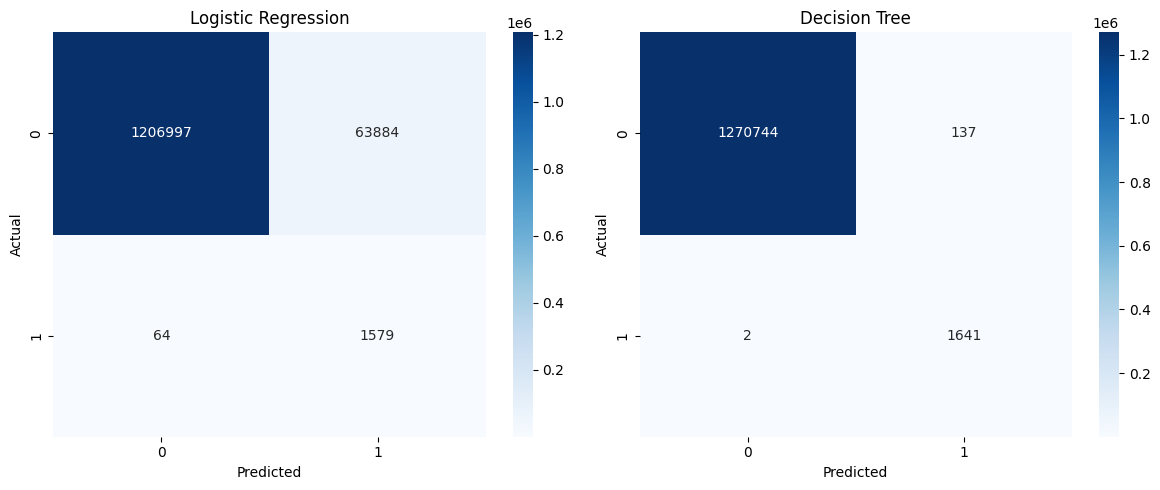

In [35]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
for ax, (name, model) in zip(axes, [("Logistic Regression", logistic_regression), ("Decision Tree", decisiontree)]):
  cm = confusion_matrix(y_test, model.predict(X_test))
  sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=ax)
  ax.set_title(name)
  ax.set_xlabel("Predicted")
  ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [36]:
import joblib

joblib.dump(decisiontree, 'fraud_model_dtree.pkl')

['fraud_model_dtree.pkl']

In [37]:
joblib.dump(logistic_regression, 'fraud_model_log_reg.pk2')

['fraud_model_log_reg.pk2']

In [38]:
import joblib

model = joblib.load("fraud_model_dtree.pkl")

print(model)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'errorBalanceOrig',
                                                   'errorBalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=8,
                                        random_state=42))])


In [39]:
import sklearn, sys
print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
scikit-learn: 1.8.0
